# Task 1


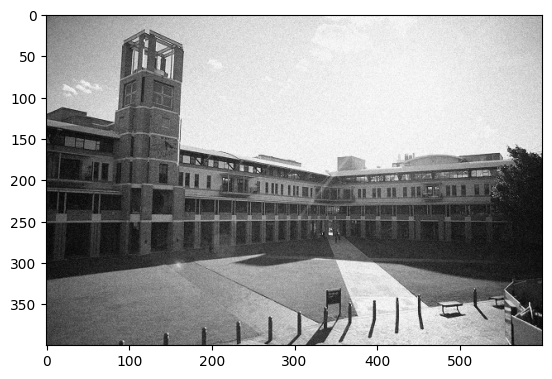

In [96]:
# Task 1 Part 1
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = "COMP9517_26T1_Lab1_Images/COMP9517_26T1_Lab1_Images"
images = []
for i in range(1, 11):
    img_path = IMAGE_DIR + "/UNSW_Campus_{:02d}.jpg".format(i)
    img = cv2.imread(img_path)
    images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

images_array = np.array(images, dtype=np.float64)
avg_image = np.mean(images_array, axis=0)
avg_image = np.clip(avg_image, 0, 255).astype(np.uint8)
cv2.imwrite("task11.jpg", cv2.cvtColor(avg_image, cv2.COLOR_RGB2BGR))
plt.imshow(avg_image)
plt.show()

Task 1 Part 2 Question 1: 
The factor should be 10^0.5

In [97]:
# Task 1 Part 2 Question 2
x1, y1, x2, y2 = 450, 110, 490, 150
noisy_region = images[0][y1:y2+1, x1:x2+1]
avg_region = avg_image[y1:y2+1, x1:x2+1]

std_noisy = np.std(noisy_region)
std_avg = np.std(avg_region)
ratio = std_noisy / std_avg

print("Sample raw image SD:{:.4f}".format(std_noisy))
print("Averaged image SD:{:.4f}".format(std_avg))
print("Ratio:{:.4f}".format(ratio))

Sample raw image SD:17.3131
Averaged image SD:5.1575
Ratio:3.3569


# Task 2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-32.40234375..30.81640625].


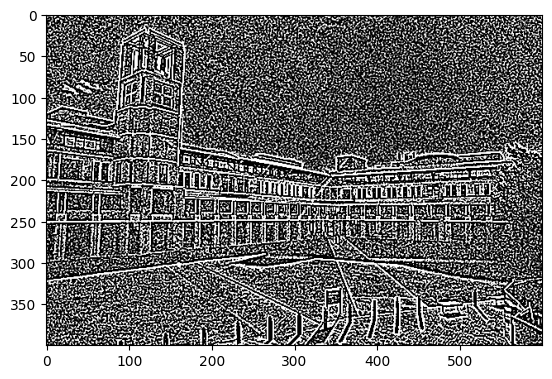

In [98]:
# Task 2 Part 1 Approach 1
img = cv2.imread("task11.jpg")
f = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float64)

h1 = np.array(
    [
        [0,0,0,0,0],
        [0,1,2,1,0],
        [0,2,4,2,0],
        [0,1,2,1,0],
        [0,0,0,0,0]
    ], dtype=np.float64
) / 16
h2 = np.array(
    [
        [ 1, 4, 6, 4, 1],
        [ 4,16,24,16, 4],
        [ 6,24,36,24, 6],
        [ 4,16,24,16, 4],
        [ 1, 4, 6, 4, 1]
    ], dtype=np.float64
) / 256
dog_kernel = h1 - h2

g1 = cv2.filter2D(f, cv2.CV_64F, dog_kernel)
plt.imshow(g1)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-32.40234375..30.81640625].


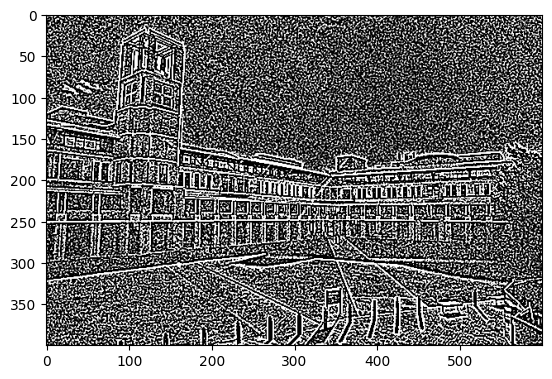

In [99]:
# Task 2 Part 1 Approach 2
img = cv2.imread("task11.jpg")
f = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float64)

h1 = np.array(
    [
        [0,0,0,0,0],
        [0,1,2,1,0],
        [0,2,4,2,0],
        [0,1,2,1,0],
        [0,0,0,0,0]
    ], dtype=np.float64
) / 16
h2 = np.array(
    [
        [ 1, 4, 6, 4, 1],
        [ 4,16,24,16, 4],
        [ 6,24,36,24, 6],
        [ 4,16,24,16, 4],
        [ 1, 4, 6, 4, 1]
    ], dtype=np.float64
) / 256

g_h1 = cv2.filter2D(f, cv2.CV_64F, h1)
g_h2 = cv2.filter2D(f, cv2.CV_64F, h2)
g2 = g_h1 - g_h2
plt.imshow(g2)
plt.show()

Tasl 2 part 2:

App1: Only one convolution is required, easy to code

App2: There are 2 intermediate images may be used for other quests

# Task 3


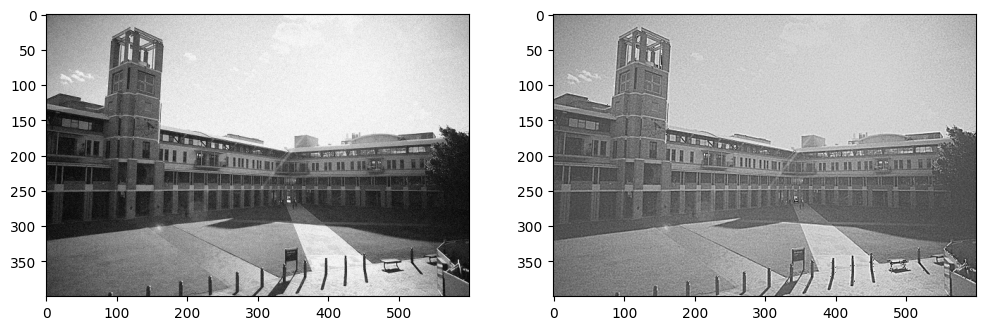

In [100]:
# Task 3 Part 1
sharpened = avg_image.astype(np.float64) + 5 * g1
sharpened = (sharpened + 110) * 0.6

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100)
axes[0].imshow(avg_image)
axes[1].imshow(sharpened.astype(np.uint8))
plt.show()

In [101]:
# Task 3 Part 2 Evidence

# Note: This line is removeing the scale and back to raw image of Task 3, which is a picture of white
sharpened = avg_image.astype(np.float64) + 5 * g1

x1, y1, x2, y2 = 450, 110, 490, 150
avg_region = avg_image[y1:y2+1, x1:x2+1]
sharpened_region = sharpened[y1:y2+1, x1:x2+1]

std_avg = np.std(avg_region)
std_sharpened = np.std(sharpened_region)

print("Sample raw image SD:{:.4f}".format(std_avg))
print("Sharpened image SD:{:.4f}".format(std_sharpened))

Sample raw image SD:5.1575
Sharpened image SD:8.2997


Task 3 Part 2 Answer

As you can see in the cell of evidence, the noise is worse than averaged image. We are tring to reduce the noise in Task 1.

It comesfrom the DoG. The DoG reduce the smooth regions and increase the edges and details. Noise is more likely to be edges and detail. So when Dog add these part, the edge become better, and noise go worse.

By the way, you can actually reduce the noise by using scale. If you change the ligtness of the image and so on, the SD will go lower. By remove the first line of evidence cell you can see that"sharpened = avg_image.astype(np.float64) + 5 * g1".